In [ ]:
import csv
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import leastsq

In [ ]:
def parse_clipboard_data(text):
    """
    Converts tabular text input (e.g. from copy-pasting) into x and y NumPy arrays.
    Assumes tab or space-separated two-column data.
    """
    # Split lines and filter out empty lines
    lines = [line.strip() for line in text.strip().splitlines() if line.strip()]
    # Split each line by whitespace or tab
    data = [list(map(float, line.split())) for line in lines]
    arr = np.array(data)
    x = arr[:, 0]
    y = arr[:, 1]
    return x, y

In [ ]:
def single_gaussian(x,params):
    (c1, mu1, sigma1, b) = params
    res =   b + c1 * np.exp( - (x - mu1)**2.0 / (2.0 * sigma1**2.0) ) 
    return res

def double_gaussian(x, params):
    (c1, mu1, sigma1, c2, mu2, sigma2,b) = params
    res =  b + c1 * np.exp( - (x - mu1)**2.0 / (2.0 * sigma1**2.0) ) \
          + c2 * np.exp( - (x - mu2)**2.0 / (2.0 * sigma2**2.0) )
    return res

def single_gaussian_fit(params,x,y):
    fit = single_gaussian(x, params)
    return (fit - y)

def double_gaussian_fit(params, x, y):
    fit = double_gaussian(x, params)
    return (fit - y)

def triple_gaussian(x, params):
    (c1, mu1, sigma1, c2, mu2, sigma2, c3, mu3, sigma3, b) = params
    return (
        b 
        + c1 * np.exp(-((x - mu1) ** 2.0) / (2.0 * sigma1 ** 2.0))
        + c2 * np.exp(-((x - mu2) ** 2.0) / (2.0 * sigma2 ** 2.0))
        + c3 * np.exp(-((x - mu3) ** 2.0) / (2.0 * sigma3 ** 2.0))
    )

def triple_gaussian_fit(params, x, y):
    fit = single_gaussian(x, params)
    return fit - y


#### lorentzians ####

def single_lorentzian(x, params):
    (c1, mu1, gamma1, b) = params
    res = b + c1 * (gamma1**2.0 / ((x - mu1)**2.0 + gamma1**2.0))
    return res

def single_lorentzian_fit(params, x, y):
    fit = single_lorentzian(x, params)
    return (fit - y)

def double_lorentzian(x, params):
    (c1, mu1, gamma1, c2, mu2, gamma2, b) = params
    return (
        b + c1 * (gamma1 ** 2.0 / ((x - mu1) ** 2.0 + gamma1 ** 2.0))
        + c2 * (gamma2 ** 2.0 / ((x - mu2) ** 2.0 + gamma2 ** 2.0))
    )

def double_lorentzian_fit(params, x, y):
    fit = double_lorentzian(x, params)
    return fit - y


def triple_lorentzian(x, params):
    (c1, mu1, gamma1, c2, mu2, gamma2, c3, mu3, gamma3, b) = params
    return (
        b + c1 * (gamma1 ** 2.0 / ((x - mu1) ** 2.0 + gamma1 ** 2.0))
        + c2 * (gamma2 ** 2.0 / ((x - mu2) ** 2.0 + gamma2 ** 2.0))
        + c3 * (gamma3 ** 2.0 / ((x - mu3) ** 2.0 + gamma3 ** 2.0))
    )

def triple_lorentzian_fit(params, x, y):
    fit = single_lorentzian(x, params)
    return fit - y

In [ ]:
raw_data = """
0	-23.445
1	-14.152
2	-18.763
3	-14.252
4	-17.617
5	29.606
6	2.900
7	4.361
8	-5.199
9	-19.937
10	-12.683
11	25.878
12	50.295
13	79.619
14	0.216
15	36.527
16	-1.578
17	24.622
18	1.321
19	16.058
20	25.857
21	-10.705
22	-16.998
23	-25.434


"""

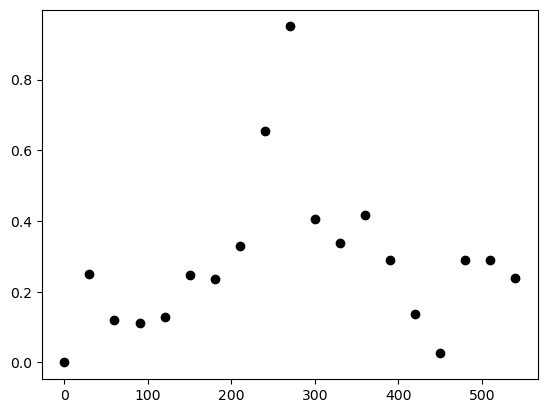

In [ ]:
x,y = parse_clipboard_data(raw_data)

pxSize=30 # Pixel size in nm
x = x * pxSize  # Convert x to nm

y=(y-np.min(y))/(np.max(y)-np.min(y))  # Normalize y
y= y * 0.95

plt.figure()
plt.plot(x, y, 'ko')
plt.show()


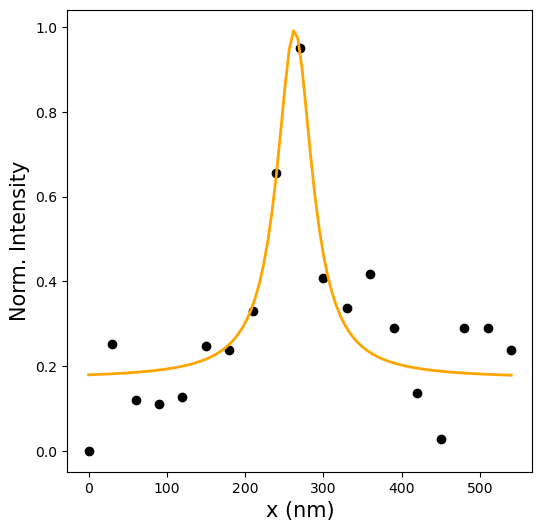

FWHM1: 54.93


In [ ]:
fit_choice = "lorentz"

x2 = np.linspace(min(x),max(x),100)

params = [
    0.95,250,60,
    0.3
]

# Least squares fit. 
fit_gauss = leastsq(single_gaussian_fit, params, args=(x, y))
fit_lorentz = leastsq(single_lorentzian_fit, params, args=(x, y))

if fit_choice == "gauss":
    fit = fit_gauss
    fwhm_factor = 2.35
else:
    fit = fit_lorentz
    fwhm_factor = 2

# Extract parameters
params1 = fit[0][:3]
bckg = fit[0][-1]

# Calculate FWHM for each Gaussian
fwhm1 = fwhm_factor * params1[2]

fig = plt.figure(figsize=(6, 6))

# Plot data and fit
if fit_choice == "gauss":
    func = single_gaussian
else:
    func = single_lorentzian

plt.plot(x, y, 'ko', markersize=6)
plt.plot(x2, func(x2, fit[0]), 'orange', linewidth=2)

# Show plot
labels_fontSize=15
ticks_prms={"labelsize":15, "width":2,"length":8}

plt.xlabel('x (nm)',fontsize=labels_fontSize)
plt.ylabel('Norm. Intensity',fontsize=labels_fontSize)



# Annotate FWHM on the plot
plt.text(params1[1]-30, params1[0] / 2-0.1, f'{fwhm1:.0f}nm', color='b')

# Add double-sided arrows for FWHM
plt.annotate('', xy=(params1[1] - fwhm1 / 2, params1[0] / 2), xytext=(params1[1] + fwhm1 / 2, params1[0] / 2),
             arrowprops=dict(arrowstyle='<->', color='b'))

plt.show()

# plot values
w1 = fit[0][2]

# FWHM
if fit_choice == "gauss":
    fwhm1 = 2.355 * abs(w1)
else:  # lorentzian
    fwhm1 = 2.0 * abs(w1)
print(f"FWHM1: {fwhm1:.2f}")
